<a href="https://colab.research.google.com/github/theMorana/HSE/blob/main/HSE/Machine%20Learning/Semester_2_Homeworks/Homework__4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В этом практикуме мы рассмотрим работу с библиотекой **Gensim** для работы с векторными представлениями текста

Мы рассмотрим
- **Word2Vec** - векторные представления слов
- **FastText** - улучшенные представления с учетом морфологии  
- **Doc2Vec** - векторные представления документов


In [ ]:
!pip install gensim

import gensim
import gensim.downloader as api
from gensim.models import Word2Vec, FastText, Doc2Vec
from gensim.models.doc2vec import TaggedDocument
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.2 MB/s eta 0:00:00


## Часть 1: Word2Vec

### Что такое Word2Vec?

Word2Vec преобразует слова в векторы чисел так, что семантически похожие слова оказываются близко в векторном пространстве.

**Два основных алгоритма:**
- **CBOW** - предсказывает слово по контексту
- **Skip-gram** - предсказывает контекст по слову

**Загрузка предобученной модели**

In [ ]:
w2v_model = api.load('glove-wiki-gigaword-100')

print(f"Размер словаря: {len(w2v_model.key_to_index)}")
print(f"Размерность векторов: {w2v_model.vector_size}")

[==================================================] 100.0% 128.1/128.1MB downloaded
Размер словаря: 400000
Размерность векторов: 100


Найдите документацию `gensim`: какие датасеты кроме `glove-wiki-gigaword-100` доступны в библиотеке?

Выберите 3 датасета и кратко опишите их (источник данных, примерный объем, зачем такой датасет может использоваться)

**Базовые операции с векторами**

In [ ]:
# Получаем вектор слова
vector = w2v_model['computer']
print(f"Вектор слова 'computer': {vector[:5]}...")  # Показываем первые 5 чисел

# Вычисляем схожесть между словами
similarity = w2v_model.similarity('computer', 'laptop')
print(f"Схожесть 'computer' и 'laptop': {similarity:.4f}")

Вектор слова 'computer': [-0.16298   0.30141   0.57978   0.066548  0.45835 ]...
Схожесть 'computer' и 'laptop': 0.7024


**Поиск похожих слов**

In [ ]:
# Находим похожие слова
similar_words = w2v_model.most_similar('python', topn=5)
print("Слова, похожие на 'python':")
for word, score in similar_words:
    print(f"  {word}: {score:.4f}")

Слова, похожие на 'python':
  monty: 0.6886
  php: 0.5865
  perl: 0.5784
  cleese: 0.5447
  flipper: 0.5113


*Ваш ответ здесь*

**Задание**

1. Загрузите любой датасет из gensim на ваш выбор

In [ ]:
dataset = api.load('text8')

[==================================================] 100.0% 31.6/31.6MB downloaded


2. Напишите функцию, которая принимает на вход любое слово и вовращает 10 наиболее близких по вектору слов

In [ ]:
def vector_similarity(word, topn=10):
  similar_words = w2v_model.most_similar(word, topn=topn)
  print(f"Слова, похожие на '{word}':")

  for i, (similar_word, similarity) in enumerate(similar_words, 1):
    print(f"{i:2d}. {similar_word:<12} | схожесть: {similarity:.3f}")

'''
word = "python"
vector_similarity(word, topn=10)
'''

test_words = ['king', 'woman', 'city', 'water', 'good']
for word in test_words:
  vector_similarity(word)

Слова, похожие на 'king':
 1. prince       | схожесть: 0.768
 2. queen        | схожесть: 0.751
 3. son          | схожесть: 0.702
 4. brother      | схожесть: 0.699
 5. monarch      | схожесть: 0.698
 6. throne       | схожесть: 0.692
 7. kingdom      | схожесть: 0.681
 8. father       | схожесть: 0.680
 9. emperor      | схожесть: 0.671
10. ii           | схожесть: 0.668
Слова, похожие на 'woman':
 1. girl         | схожесть: 0.847
 2. man          | схожесть: 0.832
 3. mother       | схожесть: 0.828
 4. boy          | схожесть: 0.772
 5. she          | схожесть: 0.763
 6. child        | схожесть: 0.760
 7. wife         | схожесть: 0.751
 8. her          | схожесть: 0.745
 9. herself      | схожесть: 0.743
10. daughter     | схожесть: 0.726
Слова, похожие на 'city':
 1. town         | схожесть: 0.826
 2. cities       | схожесть: 0.776
 3. where        | схожесть: 0.755
 4. area         | схожесть: 0.746
 5. downtown     | схожесть: 0.744
 6. capital      | схожесть: 0.713
 7. souther

3. Обучите модель Word2Vec на тестовом датасете из ячейки ниже

Примените следующие настройки:

- размер вектора: 50
- размер окна: 3
- минимальная частота слова: 1
- потоков: 2
- использовать skip-gram

In [ ]:
cooking_sentences = [
    ['варить', 'суп', 'овощи', 'морковь', 'картофель'],
    ['жарить', 'курица', 'сковорода', 'масло', 'специи'],
    ['печь', 'хлеб', 'мука', 'дрожжи', 'духовка'],
    ['резать', 'овощи', 'салат', 'помидоры', 'огурцы'],
    ['смешивать', 'ингредиенты', 'тесто', 'яйца', 'молоко'],
    ['варить', 'паста', 'вода', 'соль', 'соус'],
    ['гриль', 'мясо', 'овощи', 'уголь', 'барбекю'],
    ['тушить', 'говядина', 'горшок', 'вино', 'травы'],
    ['запекать', 'рыба', 'лимон', 'духовка', 'фольга'],
    ['готовить', 'завтрак', 'яичница', 'бекон', 'тост'],
    ['месить', 'тесто', 'пирог', 'начинка', 'яблоки'],
    ['кипятить', 'вода', 'чай', 'кофе', 'чашка'],
    ['мариновать', 'мясо', 'соус', 'специи', 'холодильник'],
    ['взбивать', 'сливки', 'сахар', 'десерт', 'торт'],
    ['парить', 'овощи', 'здоровое', 'питание', 'брокколи']
]

In [ ]:
model = Word2Vec(
    sentences=cooking_sentences,
    vector_size=50,      # размерность векторов
    window=3,             # размер контекстного окна
    min_count=1,          # минимальная частота слова
    workers=2,            # количество ядер
    sg=1                  # 0 = CBOW, 1 = Skip-Gram
)

print(f"Размер словаря: {len(model.wv.key_to_index)}")

Размер словаря: 65


In [ ]:
print(f"Слова в словаре: {list(model.wv.key_to_index.keys())[:10]}...")

Слова в словаре: ['овощи', 'мясо', 'соус', 'вода', 'тесто', 'духовка', 'специи', 'варить', 'брокколи', 'питание']...


4. Проверьте модель

In [ ]:
# Проверяем похожие слова в кулинарной тематике
try:
    similar = model.wv.most_similar('варить', topn=5)
    print("Слова, похожие на 'варить':")
    for word, score in similar:
        print(f"  {word}: {score:.4f}")
except KeyError:
    print("Слово 'варить' не найдено в словаре")

Слова, похожие на 'варить':
  вино: 0.2398
  ингредиенты: 0.2172
  хлеб: 0.1938
  брокколи: 0.1846
  кипятить: 0.1711


In [ ]:
# Найдите слова, похожие на "духовка"
### ваш код здесь ###
try:
    similar = model.wv.most_similar('духовка', topn=5)
    print("Слова, похожие на 'духовка':")
    for word, score in similar:
        print(f"  {word}: {score:.4f}")
    print()
except KeyError:
    print("Слово 'варить' не найдено в словаре")

# Найдите слова, похожие на "овощи"
### ваш код здесь ###

try:
    similar = model.wv.most_similar('овощи', topn=5)
    print("Слова, похожие на 'овощи':")
    for word, score in similar:
        print(f"  {word}: {score:.4f}")
    print()
except KeyError:
    print("Слово 'варить' не найдено в словаре")


Слова, похожие на 'духовка':
  ингредиенты: 0.3199
  десерт: 0.3064
  холодильник: 0.2705
  питание: 0.2243
  пирог: 0.2142

Слова, похожие на 'овощи':
  мариновать: 0.2716
  хлеб: 0.2691
  гриль: 0.2546
  фольга: 0.2409
  сахар: 0.2108



## Часть 2: FastText

FastText улучшает Word2Vec, рассматривая слова как наборы символов (n-грамм). Это позволяет работать с редкими словами и опечатками

5. Обучите FastText на корпусе текстов из пункта 3. Используйте код ниже

In [ ]:
ft_model = FastText(
    sentences=cooking_sentences,
    vector_size=50,
    window=3,
    min_count=1,
    workers=2
)

6. Найдите слова, похожие на "варить", "духовка" и "овощи" с помощью обученной модели. Используйте код из пункта 4

In [ ]:
try:
    similar = ft_model.wv.most_similar('варить', topn=5)
    print("Слова, похожие на 'варить':")
    for word, score in similar:
        print(f"  {word}: {score:.4f}")
except KeyError:
    print("Слово 'варить' не найдено в словаре")

try:
    similar = ft_model.wv.most_similar('духовка', topn=5)
    print("Слова, похожие на 'духовка':")
    for word, score in similar:
        print(f"  {word}: {score:.4f}")
    print()
except KeyError:
    print("Слово 'варить' не найдено в словаре")


try:
    similar = ft_model.wv.most_similar('овощи', topn=5)
    print("Слова, похожие на 'овощи':")
    for word, score in similar:
        print(f"  {word}: {score:.4f}")
    print()
except KeyError:
    print("Слово 'варить' не найдено в словаре")

Слова, похожие на 'варить':
  жарить: 0.5353
  парить: 0.4805
  месить: 0.3541
  тушить: 0.3405
  специи: 0.2622
Слова, похожие на 'духовка':
  взбивать: 0.4565
  лимон: 0.3561
  салат: 0.3050
  курица: 0.3041
  тост: 0.2944

Слова, похожие на 'овощи':
  жарить: 0.2960
  фольга: 0.2574
  морковь: 0.2297
  соус: 0.2172
  торт: 0.2094



7. Сравните модели

Дана функция для сравнения Word2Vec и FastText

Придумайте 3 слова с опечатками и проверьте, найдет ли их FastText и Word2Vec

In [ ]:
def compare_models(word):
    """Сравнивает представления слова в разных моделях"""
    print(f"\nСравнение для слова: '{word}'")

    # Word2Vec
    try:
        w2v_similar = model.wv.most_similar(word, topn=2)
        print(f"  Word2Vec: {[w for w, _ in w2v_similar]}")
    except KeyError:
        print(f"  Word2Vec: слово не найдено")

    # FastText
    try:
        ft_similar = ft_model.wv.most_similar(word, topn=2)
        print(f"  FastText: {[w for w, _ in ft_similar]}")
    except KeyError:
        print(f"  FastText: слово не найдено")

# Сравниваем для разных слов
compare_models('learning')
compare_models('neural')

compare_models('духоввк')
compare_models('овщи')
compare_models('вартит')


Сравнение для слова: 'learning'
  Word2Vec: слово не найдено
  FastText: ['духовка', 'пирог']

Сравнение для слова: 'neural'
  Word2Vec: слово не найдено
  FastText: ['мука', 'травы']

Сравнение для слова: 'духоввк'
  Word2Vec: слово не найдено
  FastText: ['духовка', 'питание']

Сравнение для слова: 'овщи'
  Word2Vec: слово не найдено
  FastText: ['овощи', 'питание']

Сравнение для слова: 'вартит'
  Word2Vec: слово не найдено
  FastText: ['уголь', 'вино']


## Часть 3: Doc2Vec

Doc2Vec расширяет Word2Vec для создания векторных представлений целых документов (предложений, абзацев, статей)

In [ ]:
# Создаем размеченные документы
documents = [
    "machine learning is interesting",
    "deep learning uses neural networks",
    "python programming for data science",
    "artificial intelligence is amazing",
    "computer vision processes images"
]

# Преобразуем в формат TaggedDocument
tagged_docs = []
for i, doc in enumerate(documents):
    tokens = doc.split()
    tagged_doc = TaggedDocument(words=tokens, tags=[f"doc_{i}"])
    tagged_docs.append(tagged_doc)

print("Размеченные документы:")
for doc in tagged_docs[:3]:
    print(f"  Слова: {doc.words}")
    print(f"  Тег: {doc.tags}")

Размеченные документы:
  Слова: ['machine', 'learning', 'is', 'interesting']
  Тег: ['doc_0']
  Слова: ['deep', 'learning', 'uses', 'neural', 'networks']
  Тег: ['doc_1']
  Слова: ['python', 'programming', 'for', 'data', 'science']
  Тег: ['doc_2']


In [ ]:
# Обучаем Doc2Vec
doc_model = Doc2Vec(
    documents=tagged_docs,
    vector_size=50,
    window=3,
    min_count=1,
    workers=2,
    epochs=20
)

print("Doc2Vec модель обучена!")
print(f"Количество документов: {len(doc_model.dv.key_to_index)}")

Doc2Vec модель обучена!
Количество документов: 5


In [ ]:
# Получаем вектор документа
doc_vector = doc_model.dv["doc_0"]
print(f"Вектор документа doc_0: {doc_vector[:5]}...")

# Находим похожие документы
similar_docs = doc_model.dv.most_similar("doc_0", topn=2)
print("\nДокументы, похожие на doc_0:")
for doc_tag, similarity in similar_docs:
    doc_id = int(doc_tag.split('_')[1])
    print(f"  {doc_tag}: {similarity:.4f}")
    print(f"    Текст: {documents[doc_id]}")

Вектор документа doc_0: [-0.01057    -0.01198188 -0.01982618  0.01710627  0.00710373]...

Документы, похожие на doc_0:
  doc_1: 0.2735
    Текст: deep learning uses neural networks
  doc_2: 0.1275
    Текст: python programming for data science


In [ ]:
# Сравниваем схожесть документов
def compare_documents(doc1_id, doc2_id):
    similarity = doc_model.dv.similarity(f"doc_{doc1_id}", f"doc_{doc2_id}")
    print(f"Схожесть doc_{doc1_id} и doc_{doc2_id}: {similarity:.4f}")
    print(f"  doc_{doc1_id}: {documents[doc1_id]}")
    print(f"  doc_{doc2_id}: {documents[doc2_id]}")

compare_documents(0, 1)  # machine learning vs deep learning
compare_documents(0, 3)  # machine learning vs AI

Схожесть doc_0 и doc_1: 0.2735
  doc_0: machine learning is interesting
  doc_1: deep learning uses neural networks
Схожесть doc_0 и doc_3: -0.0822
  doc_0: machine learning is interesting
  doc_3: artificial intelligence is amazing


8. Сравните схожесть doc_2 и doc_4

In [ ]:
#Сравниваем
compare_documents(2, 4)

Схожесть doc_2 и doc_4: -0.0362
  doc_2: python programming for data science
  doc_4: computer vision processes images


9. Найдите самый похожий документ на doc_1

In [ ]:
def the_best_similar(doc1_id):
    best_match = doc_model.dv.most_similar(f"doc_{doc1_id}", topn=1)[0]
    best_doc, similarity = best_match  # распаковываем кортеж

    best_id = int(best_doc.split('_')[1])
    print(f"Самый похожий на doc_{doc1_id}: doc_{best_id} (схожесть: {similarity:.4f})")

the_best_similar(1)

Самый похожий на doc_1: doc_0 (схожесть: 0.2735)


10. Выберите любую из трёх моделей. Обучите модели с разной размерностью (10, 50, 100). Продемонстрируйте качество их работы на примере поиска похожих слов (выберите любые 3 примера, соответствующих тематике корпуса из пункта 4)

Параметры 10

In [ ]:
def train_and_test(sentences, sizes=[10, 50, 100], topn=5):
    """
    Обучает Word2Vec модели с разными vector_size и тестирует на слове

    Args:
        sentences: список предложений для обучения
        sizes: список размеров векторов для тестирования
        test_word: слово для проверки схожести
        topn: количество топовых похожих слов
    """
    models = {}

    for size in sizes:
        print(f"\nОбучаем model_{size}")

        # Обучаем модель
        model = Word2Vec(
            sentences=sentences,
            vector_size=size,
            window=3,
            min_count=1,
            workers=2,
            sg=1
        )
        models[f'model_{size}'] = model
        print(f"Размер словаря: {len(model.wv.key_to_index):,}")

        # Тестируем слово
        try:
            similar = model.wv.most_similar('вино', topn=topn)
            print(f"Слова, похожие на 'вино':")
            for word, score in similar:
                print(f"  {word}: {score:.4f}")
        except KeyError:
            print(f"Слово 'вино' не найдено в словаре")

    return models

# 🔥 ИСПОЛЬЗОВАНИЕ:
models = train_and_test(
    sentences=cooking_sentences,
    sizes=[10, 50, 100],
)

# Теперь у тебя есть model_10, model_50, model_100 в словаре models
model_10 = models['model_10']
model_50 = models['model_50']
model_100 = models['model_100']



Обучаем model_10
Размер словаря: 65
Слова, похожие на 'вино':
  уголь: 0.6672
  овощи: 0.5329
  мясо: 0.5222
  дрожжи: 0.5074
  молоко: 0.3795

Обучаем model_50
Размер словаря: 65
Слова, похожие на 'вино':
  сливки: 0.2399
  варить: 0.2398
  тост: 0.2365
  пирог: 0.2242
  брокколи: 0.2032

Обучаем model_100
Размер словаря: 65
Слова, похожие на 'вино':
  специи: 0.3489
  соль: 0.2652
  торт: 0.2481
  яйца: 0.2289
  варить: 0.2039


In [ ]:
print(type(models), type(similar), type(score))

<class 'dict'> <class 'list'> <class 'numpy.float64'>


Бонус - график сравнения результатов для анализа лучших параметров.

Результаты:
vector_size=10: 0.522
vector_size=50: 0.229
vector_size=100: 0.259


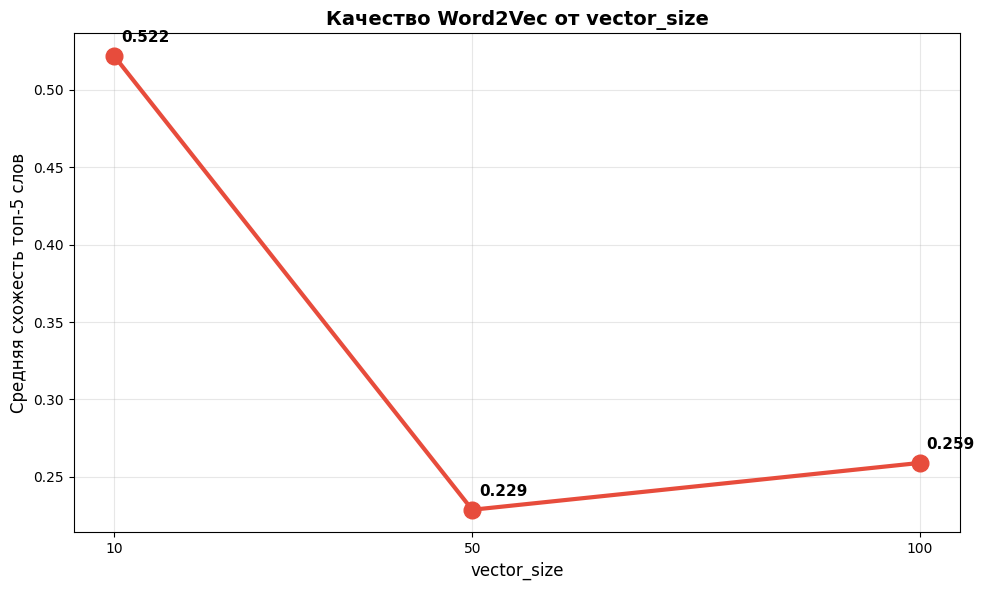

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt



# Считаем качество для 3 параметров
def evaluate_model(model):
  '''
  Функция переводит схожесть слов в число
  '''
  test_words = ['вино']
  total = 0
  count = 0
  for word in test_words:
      try:
          similar = model.wv.most_similar(word, topn=5)
          avg_sim = np.mean([score for _, score in similar])
          total += avg_sim
          count += 1
      except KeyError:
          pass
  return total / count if count > 0 else 0

# Результаты
scores_10 = evaluate_model(model_10)
scores_50 = evaluate_model(model_50)
scores_100 = evaluate_model(model_100)

results = {10: scores_10, 50: scores_50, 100: scores_100}
print("Результаты:")
for size, score in results.items():
    print(f"vector_size={size}: {score:.3f}")

# ГРАФИК
plt.figure(figsize=(10, 6))
sizes = [10, 50, 100]
scores = [scores_10, scores_50, scores_100]

plt.plot(sizes, scores, marker='o', linewidth=3, markersize=12, color='#e74c3c')
plt.title('Качество Word2Vec от vector_size', fontweight='bold', fontsize=14)
plt.xlabel('vector_size', fontsize=12)
plt.ylabel('Средняя схожесть топ-5 слов', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(sizes)

# Подписи
for size, score in zip(sizes, scores):
    plt.annotate(f'{score:.3f}', (size, score),
                xytext=(5, 10), textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()
